<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 192.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 208.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 168.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 175.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 105.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 188.8 MB/s eta 0:00:00


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
## Write your code here
print("===Data Info===")
print(df.info())

print("===Summary Statistics===")
print(df.describe())

print("\n=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

===Data Info===
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None
===Summary Statistics===
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65447.000000   3.374000e+04  29659.000000    29325.000000   
mean   32714.001528  2.963841e+145     11.467143       18.580460   
std    18893.063225  5.444117e+147      9.168610       25.966005   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16352.500000   6.000000e+04      4.000000        0.000000   
50%    32714.000000   1.100000e+05      9.000000       10.000000   
75%    49075.500000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29394.000000    29412.000000    29451.000000    29449.000000   
mean         7.521884    

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here
# Count missing values per column
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a neat summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})

# Show only columns that have missing values, sorted by most missing
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print(missing_summary)

                            Missing Count  Missing Percentage
AINextMuch less integrated          64299           98.245909
AINextLess integrated               63092           96.401669
AINextNo change                     52947           80.900576
AINextMuch more integrated          52008           79.465827
EmbeddedAdmired                     48711           74.428163
...                                   ...                 ...
YearsCode                            5569            8.509175
NEWSOSites                           5151            7.870491
LearnCode                            4949            7.561844
EdLevel                              4653            7.109570
AISelect                             4530            6.921631

[109 rows x 2 columns]


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



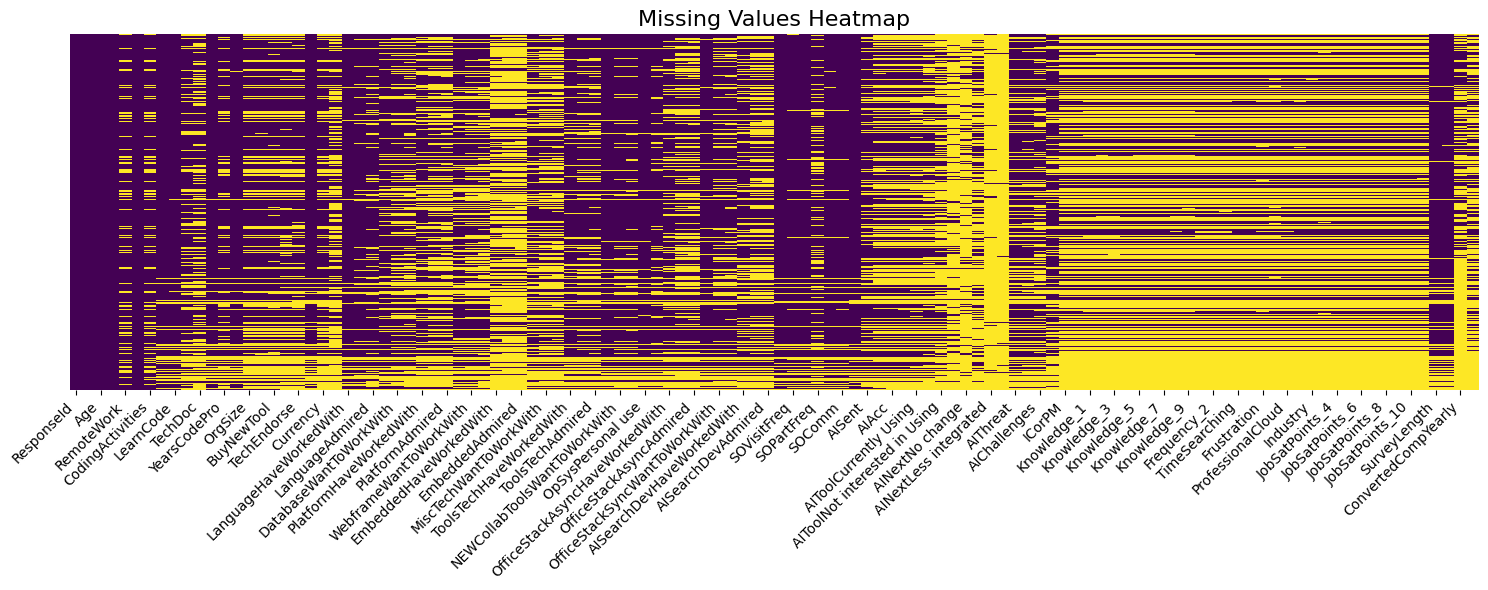

In [6]:
## Write your code here
# Visualize missing values using a heatmap
plt.figure(figsize=(15, 6))

sns.heatmap(df.isnull(), 
            cbar=False,          # No color bar needed (True/False is enough)
            yticklabels=False,   # Hide row labels (too many rows)
            cmap='viridis')      # Yellow = missing, Purple = present

plt.title('Missing Values Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [7]:
# Count missing values in the Employment column
missing_employment = df['Employment'].isnull().sum()

# Calculate the percentage
missing_employment_percent = (missing_employment / len(df)) * 100

print(f"Missing values in 'Employment' column: {missing_employment}")
print(f"Percentage missing: {missing_employment_percent:.2f}%")

Missing values in 'Employment' column: 0
Percentage missing: 0.00%


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [9]:
# Find the most frequent value (mode) in the Employment column
most_frequent = df['Employment'].value_counts()

print("=== Employment Value Counts ===")
print(most_frequent)

print(f"\nMost Frequent Value: '{df['Employment'].mode()[0]}'")
print(f"Frequency: {most_frequent.iloc[0]} times")

=== Employment Value Counts ===
Employment
Employed, full-time                                                                                                                                   39046
Independent contractor, freelancer, or self-employed                                                                                                   4847
Student, full-time                                                                                                                                     4712
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but loo

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [10]:
## Write your code here
# Get the most frequent value
most_frequent_value = df['Employment'].mode()[0]

# Check missing values BEFORE imputation
print(f"Missing values BEFORE imputation: {df['Employment'].isnull().sum()}")

# Fill missing values with the most frequent value
df['Employment'].fillna(most_frequent_value, inplace=True)

# Check missing values AFTER imputation
print(f"Missing values AFTER imputation: {df['Employment'].isnull().sum()}")

print(f"\nAll missing values have been replaced with: '{most_frequent_value}'")

Missing values BEFORE imputation: 0
Missing values AFTER imputation: 0

All missing values have been replaced with: 'Employed, full-time'


/tmp/ipykernel_300/2488872594.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Employment'].fillna(most_frequent_value, inplace=True)


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


In [ ]:
## Write your code here
# Visualize the distribution of Employment column after imputation
plt.figure(figsize=(12, 6))

ax = df['Employment'].value_counts().plot(kind='bar', 
                                           color='steelblue',
                                           edgecolor='black')

plt.title('Employment Distribution After Imputation', fontsize=16)
plt.xlabel('Employment Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_300/399621331.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
